Importing Packages
---

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import scipy.optimize as op
from sklearn.model_selection import train_test_split
from scipy.interpolate import griddata

Loading Dataset
---

In [2]:
#Separating dataset
def separate_files(file_pattern):
    #Reading labels from the file names
    all_files = glob.glob(file_pattern)
    phases = []
    for file_path in all_files:
        basename = os.path.basename(file_path)
        name_without_ext = os.path.splitext(basename)[0]
        tokens = name_without_ext.split('_')
        phases.append(1 if tokens[2] == 'above' else 0)
     
    list_train, list_test = train_test_split(
    all_files, test_size=0.15, stratify=phases, random_state=42
    )
    return list_train, list_test

#A portion of the data is stored in the file name, we read these separately from the actual
#matrices, so that they may be cycled in and out of memory as necessary.
def read_file_parameters(file_path):
    basename = os.path.basename(file_path)
    name_without_ext = os.path.splitext(basename)[0]
    tokens = name_without_ext.split('_')

    beta  = float(tokens[0])
    h = float(tokens[1])
    phase = 1 if tokens[2] == 'above' else 0
    
    return beta, h, phase

def load_directory(file_pattern):
    list_train, list_test = separate_files(file_pattern)

    parameters_train = [read_file_parameters(file_path) for file_path in list_train]
    parameters_test = [read_file_parameters(file_path) for file_path in list_test]

    betas_train, hs_train, phases_train = np.array(parameters_train).T
    betas_test, hs_test, phases_test = np.array(parameters_test).T
    #With this we now have an array of each parameter and a list of files separated
    #into train and test sets

    return (list_train, betas_train, hs_train, phases_train,
            list_test, betas_test, hs_test, phases_test)

#Loading dataset
(list_train, betas_train, hs_train, phases_train,
 list_test, betas_test, hs_test, phases_test) = load_directory("../2dIsingData/zero_h/*.npz")

#A bit roundabout, but will be necessary in order for homogeneous sampling of betas across datasets

The Data
---
We have two datasets, one with varying temperatures and no external field, and another with varying external positive field.

The following is a visualization of the system we will be investigating

(Note that the first and last rows and columns are fixed:)
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1.] 



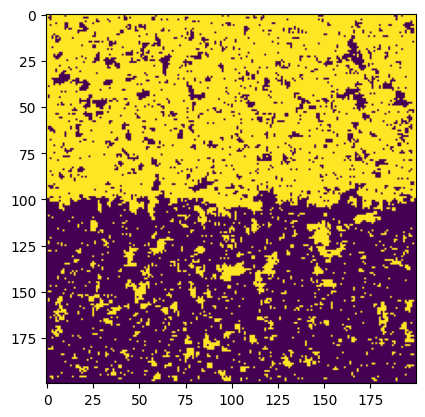

In [3]:
def matrix_from_file(file_path):
    with np.load(file_path) as data:
        matrix = data['sigma'].copy()
    return matrix
    
np.random.seed(3)
sample_number = np.random.randint(0, len(list_train))
example_grid = matrix_from_file(list_train[sample_number])

print("The following is a visualization of the system we will be investigating\n")
plt.imshow(example_grid)

print("(Note that the first and last rows and columns are fixed:)\n", example_grid[0], "\n")

Fully Connected Network for the h = 0 dataset
---

In [4]:
#Build the model
N = 200
FCNN_zero_h = models.Sequential([
    layers.Input(shape=(N**2,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

FCNN_zero_h.compile( 
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [5]:
#Training the model

#This might seem redundant as there are built in one-liners for this in the libraries
#that we are using in this discussion, but this function rotates the training matrices
#in and out of RAM in batches.
#This will be relevant for the other dataset which is quite large.
def train_by_batch(model, list_train, phases_train, flatten, BATCH_SIZE, EPOCHS):
    num_samples = len(list_train)

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch + 1}/{EPOCHS}")
        
        epoch_loss = 0
        epoch_acc = 0
        batch_count = 0
        
        for i in range(0, num_samples, BATCH_SIZE):
            batch_files = list_train[i : i + BATCH_SIZE]
            batch_labels = phases_train[i : i + BATCH_SIZE]
            
            batch_features = []
            for file_path in batch_files:
                with np.load(file_path) as data:
                    batch_features.append(data['sigma'].copy())

            if(flatten == 1):
                X_batch = np.array(batch_features).reshape(len(batch_files), -1)
            else:
                X_batch = np.array(batch_features)[..., np.newaxis]
            y_batch = np.array(batch_labels)
            
            metrics = model.train_on_batch(X_batch, y_batch)
            
            # Accumulate metrics across all batches
            epoch_loss += metrics[0]
            epoch_acc += metrics[1]
            batch_count += 1

        # Calculate and print the true global metric of the dataset
        print(f"Average Loss: {epoch_loss / batch_count:.4f} - Average Accuracy: {epoch_acc / batch_count:.4f}")


Visualizing the critical temperature using the model
---

In [6]:
#Now for the training
train_by_batch(FCNN_zero_h, list_train, phases_train, flatten=1, BATCH_SIZE=64, EPOCHS=20)


Epoch 1/20
Average Loss: 4.6784 - Average Accuracy: 0.5969

Epoch 2/20
Average Loss: 6.3630 - Average Accuracy: 0.6362

Epoch 3/20
Average Loss: 4.9793 - Average Accuracy: 0.6851

Epoch 4/20
Average Loss: 3.9843 - Average Accuracy: 0.6953

Epoch 5/20
Average Loss: 3.4865 - Average Accuracy: 0.7133

Epoch 6/20
Average Loss: 3.0417 - Average Accuracy: 0.7350

Epoch 7/20
Average Loss: 2.6360 - Average Accuracy: 0.7542

Epoch 8/20
Average Loss: 2.3387 - Average Accuracy: 0.7747

Epoch 9/20
Average Loss: 2.1090 - Average Accuracy: 0.7910

Epoch 10/20
Average Loss: 1.8975 - Average Accuracy: 0.8110

Epoch 11/20
Average Loss: 1.7227 - Average Accuracy: 0.8282

Epoch 12/20
Average Loss: 1.5782 - Average Accuracy: 0.8411

Epoch 13/20
Average Loss: 1.4553 - Average Accuracy: 0.8524

Epoch 14/20
Average Loss: 1.3487 - Average Accuracy: 0.8632

Epoch 15/20
Average Loss: 1.2571 - Average Accuracy: 0.8726

Epoch 16/20
Average Loss: 1.1770 - Average Accuracy: 0.8808

Epoch 17/20
Average Loss: 1.1063

In [7]:
literature_beta = 0.4407
#A steep sigmoid for fitting
def smooth_crit_temp(beta, a, k=50):
    return 1 / (1 + np.exp(k * (beta - a)))

#Visualizes model performance
def fit_critical(betas_test, phases_test, predictions, title):
    plt.scatter(betas_test, phases_test, label='Ground truth', marker = '3')
    plt.scatter(betas_test, predictions, label='Model\'s last layer', marker = '4')
    popt, pcov = op.curve_fit(smooth_crit_temp, betas_test, predictions.flatten(), p0=[0.4])
    plt.vlines(popt[0], 0, 1, colors='b', linestyles='dashed', label=f'Fit Critical Beta: {popt[0]:.4f}')
    plt.vlines(literature_beta, 0, 1, colors='r', linestyles='dashed', label=f'Literature Beta: {literature_beta:.4f}')
    plt.xlabel("Inverse temperature beta")
    plt.ylabel("Above critical or not")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


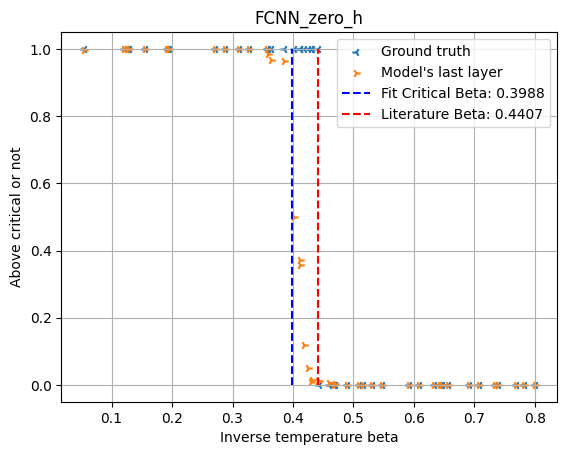

In [8]:
test_matrices = np.array([matrix_from_file(file_path) for file_path in list_test])
predictions = FCNN_zero_h.predict(test_matrices.reshape(len(list_test), -1))
fit_critical(betas_test, phases_test, predictions,"FCNN_zero_h")

The model performs fairly well, but as we'll see it and others similar to it consistently converge such that they overestimate T_c (Or equivalently -under Beta_c). This is likely due to having broken the positive/negative symmetry of the problem somewhere along the way. For instance with the use of ReLU and later with the magnetic field being strictly positive.

Fitting on Submatrices
---

In [9]:
def random_crop(matrix, size):
    h, w = matrix.shape
    # Calculate the maximum valid starting indices to prevent out-of-bounds errors
    max_h = h - size
    max_w = w - size
    
    # Pick random starting coordinates
    start_h = np.random.randint(0, max_h + 1)
    start_w = np.random.randint(0, max_w + 1)
    
    return matrix[start_h : start_h + size, start_w : start_w + size]

#Excuse the repetition.
def train_by_batch_crop(model, list_train, phases_train, flatten, BATCH_SIZE, EPOCHS, CROP):
    num_samples = len(list_train)

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch + 1}/{EPOCHS}")
        
        epoch_loss = 0
        epoch_acc = 0
        batch_count = 0
        
        for i in range(0, num_samples, BATCH_SIZE):
            batch_files = list_train[i : i + BATCH_SIZE]
            batch_labels = phases_train[i : i + BATCH_SIZE]
            
            batch_features = []
            for file_path in batch_files:
                with np.load(file_path) as data:
                    batch_features.append(random_crop(data['sigma'].copy(), CROP))

            if(flatten == 1):
                X_batch = np.array(batch_features).reshape(len(batch_files), -1)
            else:
                X_batch = np.array(batch_features)[..., np.newaxis]
            y_batch = np.array(batch_labels)
            
            metrics = model.train_on_batch(X_batch, y_batch)
            
            # Accumulate metrics across all batches
            epoch_loss += metrics[0]
            epoch_acc += metrics[1]
            batch_count += 1

        # Calculate and print the true global metric of the dataset
        print(f"Average Loss: {epoch_loss / batch_count:.4f} - Average Accuracy: {epoch_acc / batch_count:.4f}")


Epoch 1/30
Average Loss: 0.9411 - Average Accuracy: 0.5397

Epoch 2/30
Average Loss: 0.8070 - Average Accuracy: 0.6309

Epoch 3/30
Average Loss: 0.7162 - Average Accuracy: 0.6615

Epoch 4/30
Average Loss: 0.6718 - Average Accuracy: 0.6785

Epoch 5/30
Average Loss: 0.6351 - Average Accuracy: 0.7007

Epoch 6/30
Average Loss: 0.6001 - Average Accuracy: 0.7204

Epoch 7/30
Average Loss: 0.5727 - Average Accuracy: 0.7343

Epoch 8/30
Average Loss: 0.5532 - Average Accuracy: 0.7427

Epoch 9/30
Average Loss: 0.5376 - Average Accuracy: 0.7530

Epoch 10/30
Average Loss: 0.5285 - Average Accuracy: 0.7593

Epoch 11/30
Average Loss: 0.5174 - Average Accuracy: 0.7658

Epoch 12/30
Average Loss: 0.5060 - Average Accuracy: 0.7723

Epoch 13/30
Average Loss: 0.4936 - Average Accuracy: 0.7792

Epoch 14/30
Average Loss: 0.4842 - Average Accuracy: 0.7844

Epoch 15/30
Average Loss: 0.4781 - Average Accuracy: 0.7868

Epoch 16/30
Average Loss: 0.4716 - Average Accuracy: 0.7899

Epoch 17/30
Average Loss: 0.4646

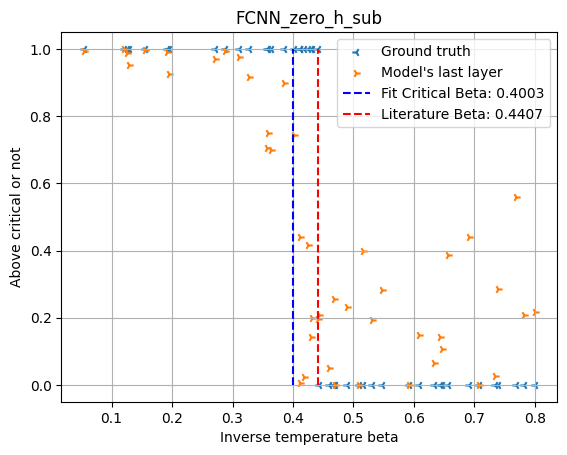

In [10]:
#We take CROP*CROP randomly positioned submatrices of the samples
CROP = 100
FCNN_zero_h_sub = models.Sequential([
    layers.Input(shape=(CROP**2,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

FCNN_zero_h_sub.compile( 
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

train_by_batch_crop(FCNN_zero_h_sub, list_train, phases_train, flatten=1, BATCH_SIZE=64, EPOCHS=30, CROP = CROP)

test_matrices = np.array([matrix_from_file(file_path) for file_path in list_test])
cropped_matrices = np.array([random_crop(test_matrix[:], CROP) for test_matrix in test_matrices])
predictions = FCNN_zero_h_sub.predict(cropped_matrices.reshape(len(list_test), -1))
fit_critical(betas_test, phases_test, predictions, "FCNN_zero_h_sub")

Unsurprisingly the result of throwing away a portion of the data is slower convergence, which manifests as uncertainty. Interestingly, values for Beta_c tend to be lower than the literature value. It is worth mentioning that the model converging for randomly positioned matrices further supports the idea, that it doesn't rely on the absolute position of features, which is remarkable as FCNs are prone to such behaviour.

Increasing the Parameter Count
---
We investigated if dramatically increasing the number of parameters results in higher predictive power. We used a higher batch size in an effort to avoid overfitting for this model.


Epoch 1/10
Average Loss: 1.2077 - Average Accuracy: 0.5657

Epoch 2/10
Average Loss: 3.1639 - Average Accuracy: 0.6137

Epoch 3/10
Average Loss: 2.7833 - Average Accuracy: 0.6590

Epoch 4/10
Average Loss: 2.3707 - Average Accuracy: 0.6741

Epoch 5/10
Average Loss: 2.2453 - Average Accuracy: 0.6821

Epoch 6/10
Average Loss: 2.1830 - Average Accuracy: 0.6898

Epoch 7/10
Average Loss: 2.1285 - Average Accuracy: 0.6924

Epoch 8/10
Average Loss: 2.0221 - Average Accuracy: 0.6942

Epoch 9/10
Average Loss: 1.9200 - Average Accuracy: 0.6973

Epoch 10/10
Average Loss: 1.8049 - Average Accuracy: 0.6987
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001EDEC786B60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) p

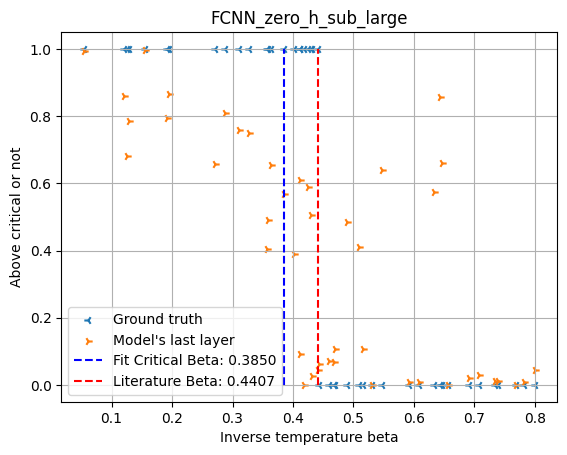

In [11]:
FCNN_zero_h_sub_large = models.Sequential([
    layers.Input(shape=(CROP**2,)),
    layers.Dense(int(CROP**2/2), activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

FCNN_zero_h_sub_large.compile( 
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

train_by_batch_crop(FCNN_zero_h_sub_large, list_train, phases_train, flatten=1, BATCH_SIZE=128, EPOCHS=10, CROP = CROP)

test_matrices = np.array([matrix_from_file(file_path) for file_path in list_test])
cropped_matrices = np.array([random_crop(test_matrix[:], CROP) for test_matrix in test_matrices])
predictions = FCNN_zero_h_sub_large.predict(cropped_matrices.reshape(len(list_test), -1))
fit_critical(betas_test, phases_test, predictions, "FCNN_zero_h_sub_large")

It appears that we ended up overfitting regardless. Our verdict is that the smaller model performes about as well as the size of the dataset allows a model with such a structure.

Note:
---
In previous versions of this discussion we came to the conclusion that the submatrix size was proportional to the value of Beta_c produced by fitting. This appears to have been an artifact of the unstratified, built-in data separation mechanism of the library we used. We stopped seeing such a relationship after having switched to custom written data separation and training functions.

Case of external magnetic field
---
This dataset is plentiful, but contains many values of h.

In [12]:
(list_train, betas_train, hs_train, phases_train,
 list_test, betas_test, hs_test, phases_test) = load_directory("../2dIsingData/non_zero_h/*.npz")

In [13]:
FCNN_h = models.Sequential([
    layers.Input(shape=(N**2,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

FCNN_h.compile( 
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
train_by_batch(FCNN_h, list_train, phases_train, flatten=1, BATCH_SIZE=32, EPOCHS=5)


Epoch 1/5
Average Loss: 1.8359 - Average Accuracy: 0.6775

Epoch 2/5
Average Loss: 0.7398 - Average Accuracy: 0.7701

Epoch 3/5
Average Loss: 0.6026 - Average Accuracy: 0.8005

Epoch 4/5
Average Loss: 0.5414 - Average Accuracy: 0.8164

Epoch 5/5
Average Loss: 0.5051 - Average Accuracy: 0.8249


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


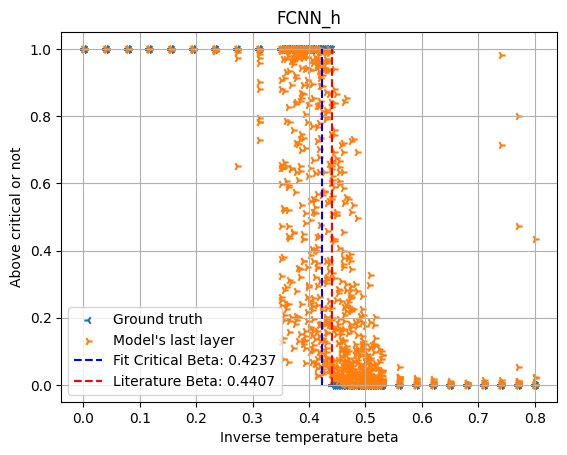

In [15]:
test_matrices = np.array([matrix_from_file(file_path) for file_path in list_test])
predictions = FCNN_h.predict(test_matrices.reshape(len(list_test), -1))
fit_critical(betas_test, phases_test, predictions, "FCNN_h")

We see serious error for the FCN, though it was accurate on avarage. Visualising along the h axis we may gain further insight:

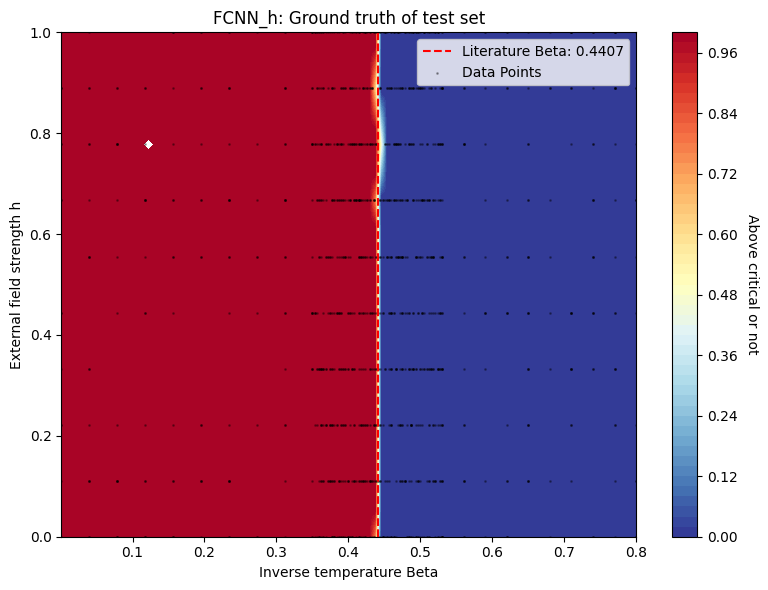

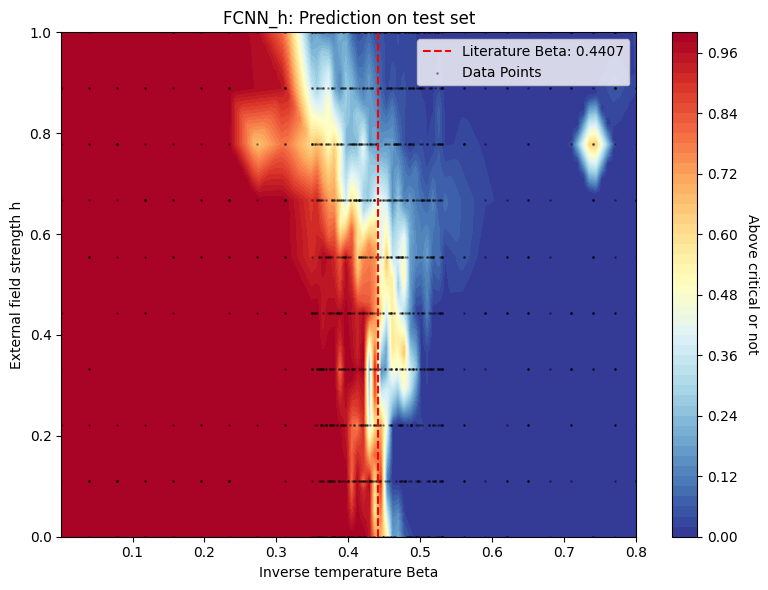

In [16]:
def plot_3D(betas, hs, perdictions, title):
    perdictions = perdictions.ravel()
    #Create a dense regular 2D grid
    x_grid = np.linspace(betas.min(), betas.max(), 100)
    y_grid = np.linspace(hs.min(), hs.max(), 100)
    X, Y = np.meshgrid(x_grid, y_grid)

    #Interpolate the data
    Z = griddata((betas, hs), perdictions, (X, Y), method='linear')

    #Plot using contourf
    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(X, Y, Z, levels=50, cmap='RdYlBu_r', vmin=0, vmax=1)

    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('Above critical or not', rotation=270, labelpad=15)
    plt.vlines(literature_beta, 0, 1, colors='r', linestyles='dashed', label=f'Literature Beta: {literature_beta:.4f}')

    ax.scatter(betas, hs, c='black', s=1, alpha=0.3, label='Data Points')

    ax.set_xlabel('Inverse temperature Beta')
    ax.set_ylabel('External field strength h')
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()

plot_3D(betas_test, hs_test, phases_test, "FCNN_h: Ground truth of test set")
plot_3D(betas_test, hs_test, predictions, "FCNN_h: Prediction on test set")

Note: Though "duplicate" datapoints technically are not accounted for during plotting, but they don't make a difference in practice.

We operated under the assumption that phase change would happen at T_c regardless of h (see first plot), this might not be true.

The figure suggests that the external magnetization acts as a source of artificial order in the system, simulating low temperature domains, and shifting the appearant Beta_c ever-lower. This is of course a mistake on the models part.

Relatively Tiny Convolutional Network
---
As the usable structures are inherently 2D, the FCNN investigation was more a curiosity than anything else. The CNN should have a much easier time interpreting its inputs, hopefully distinguishing between magnetization due to external fields and natural domains.

In [ ]:
CNN = models.Sequential([
    layers.Input(shape=(N, N, 1)),

    # Using LeakyReLU prevents zeroing out valid negative spin structural features
    layers.Conv2D(16, (5, 5), padding='valid'),
    layers.LeakyReLU(negative_slope=0.1),
    # Respects sign and acts like local coarse-graining 
    layers.AveragePooling2D((2, 2)), 
    
    layers.Conv2D(32, (5, 5), padding='valid'),
    layers.LeakyReLU(negative_slope=0.1),
    layers.AveragePooling2D((2, 2)),
    
    #Avarage together the 32 layers
    layers.GlobalAveragePooling2D(),
    # Standard ReLU is fine in the global neck
    layers.Dense(36, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

CNN.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
train_by_batch(CNN, list_train, phases_train, flatten=0, BATCH_SIZE=64, EPOCHS=5)


Epoch 1/5
Average Loss: 0.4928 - Average Accuracy: 0.7936

Epoch 2/5
Average Loss: 0.3130 - Average Accuracy: 0.8755

Epoch 3/5
Average Loss: 0.2562 - Average Accuracy: 0.8957

Epoch 4/5
Average Loss: 0.2254 - Average Accuracy: 0.9077

Epoch 5/5
Average Loss: 0.2059 - Average Accuracy: 0.9154


In [21]:
train_matrices = np.array([matrix_from_file(file_path) for file_path in list_train])
predictions_train = CNN.predict(train_matrices)

test_matrices = np.array([matrix_from_file(file_path) for file_path in list_test])
predictions_test = CNN.predict(test_matrices)

213/213 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


Let's see predictions on the training set first for a change


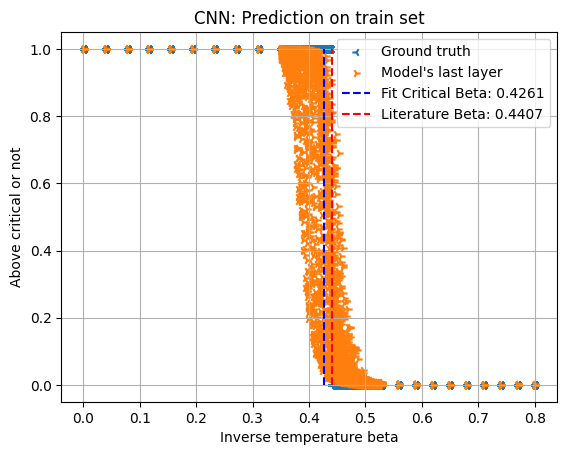

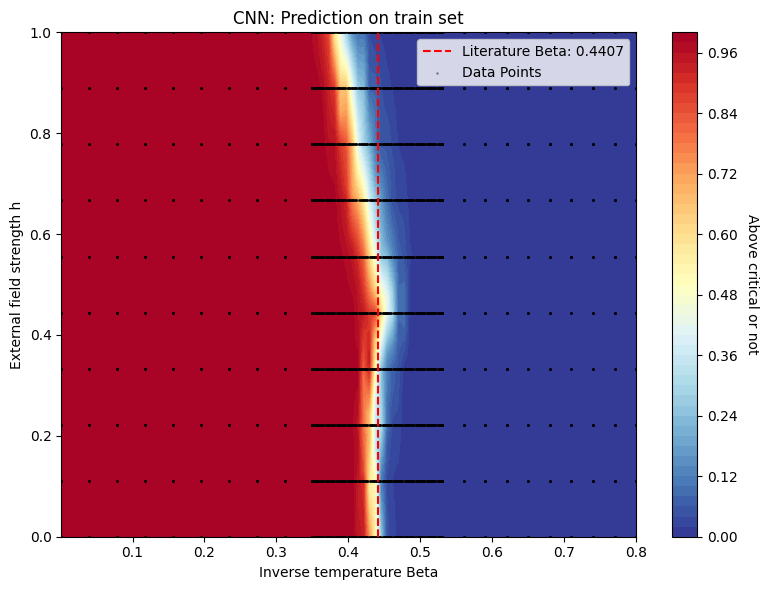

Predictions on test set


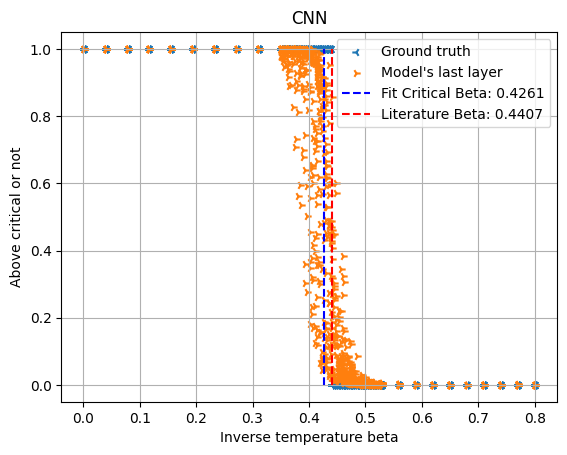

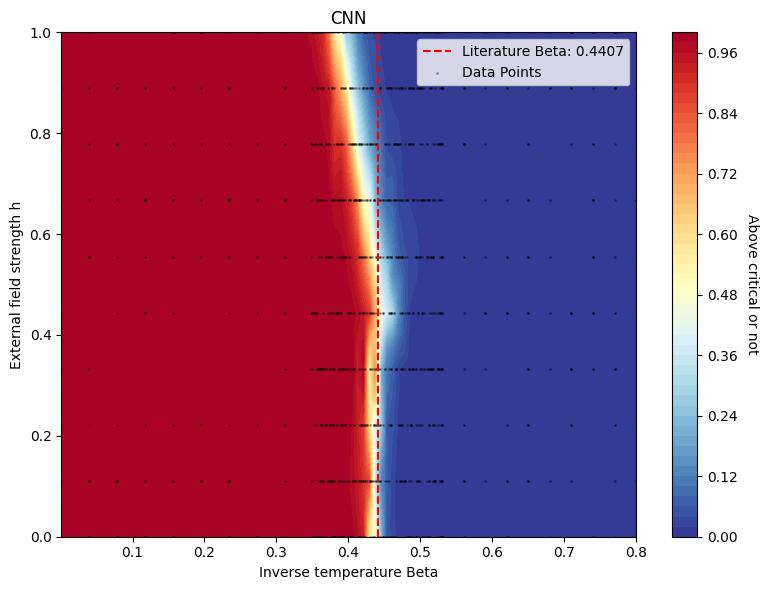

In [22]:
print("Let's see predictions on the training set first for a change")
fit_critical(betas_train, phases_train, predictions_train, "CNN: Prediction on train set")
plot_3D(betas_train, hs_train, predictions_train, "CNN: Prediction on train set")

print("Predictions on test set")
fit_critical(betas_test, phases_test, predictions_test, "CNN")
plot_3D(betas_test, hs_test, predictions_test, "CNN")

Some downshifting still occours, but the results speak for themselves. The model is generally correct about the systems phase, regardless of external field strength. Though the downshifting appears to be a linear function of the field above 0.5, the deviation is not as simple in the lower half, which warrants further investigation.